In [1]:
import time
import datetime

# Third-party imports
import numpy as np
import pandas as pd
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from IPython.display import display
from scipy.optimize import linear_sum_assignment
from matplotlib.lines import Line2D

# Modeling and probabilistic imports
import liesel.model as lsl
import liesel.goose as gs
from tensorflow_probability.substrates.jax.experimental import distributions as tfde
from tensorflow_probability.python.internal.backend.jax.compat import v2 as tf
import tensorflow_probability.substrates.jax.distributions as tfd
import tensorflow_probability.substrates.jax.bijectors as tfb

# ==============================================================================
# Setup & Styling
# ==============================================================================
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (16, 9)

In [ ]:
# ==============================================================================
# 1. DATA SIMULATION
# ==============================================================================
def generate_mixture_simulated_data(
    n_units=2000, n_obs=100, n_alts=4, n_components=2, n_params=None, 
    n_demos=2, custom_pvec=None, custom_indicators=None, seed=123):
    """
    Generates synthetic panel data for a Hierarchical Multinomial Logit (HMNL) model 
    with a mixture-of-normals prior, based on Rossi et al (2006).
    """
    np.random.seed(seed)
    
    if n_params is None:
        n_params = n_alts 
        
    if n_params < n_alts - 1:
        raise ValueError(
            f"n_params ({n_params}) must be at least n_alts - 1 "
            f"({n_alts - 1}) for Alternative Specific Constants (ASCs)"
        )

    n_ascs = n_alts - 1
    n_continuous = n_params - n_ascs

    # Generate Demographic Data (Z)
    Z = np.random.normal(0, 1, size=(n_units, n_demos))
    Z = Z - np.mean(Z, axis=0) 

    # Generate TRUE Global & Mixture Parameters
    Delta_true = np.random.normal(0, 0.5, size=(n_demos, n_params))

    if custom_pvec is not None:
        if len(custom_pvec) != n_components:
            raise ValueError(f"custom_pvec length must match n_components")
        true_pvec = np.array(custom_pvec)
        true_pvec = true_pvec / np.sum(true_pvec) 
    else:
        raw_p = np.random.uniform(0.5, 2.0, n_components)
        true_pvec = raw_p / np.sum(raw_p) 

    true_mu_k = np.random.normal(0, 2.0, size=(n_components, n_params))

    true_Sigma_k = np.zeros((n_components, n_params, n_params))
    for k in range(n_components):
        true_Sigma_k[k] = np.diag(np.random.uniform(0.5, 2.0, n_params))

    # Generate Individual-Level Parameters
    beta_true = np.zeros((n_units, n_params))
    
    if custom_indicators is not None:
        if len(custom_indicators) != n_units:
            raise ValueError("custom_indicators length must match n_units")
        true_indicators = np.array(custom_indicators)
    else:
        true_indicators = np.random.choice(n_components, size=n_units, p=true_pvec)

    for i in range(n_units):
        k = true_indicators[i]
        mu_i = Z[i] @ Delta_true + true_mu_k[k]
        beta_true[i] = np.random.multivariate_normal(mu_i, true_Sigma_k[k])

    # Generate Choice Data
    X_list, y_list, unit_idx_list = [], [], []

    for i in range(n_units):
        for t in range(n_obs):
            X_it = np.zeros((n_alts, n_params))
            for a in range(1, n_alts):
                X_it[a, a - 1] = 1.0

            if n_continuous > 0:
                X_it[:, n_ascs:] = np.random.uniform(1.0, 5.0, size=(n_alts, n_continuous))

            U_it = X_it @ beta_true[i]
            U_it_max = np.max(U_it)
            exp_U = np.exp(U_it - U_it_max)
            probs = exp_U / np.sum(exp_U)

            y_it = np.random.choice(n_alts, p=probs)

            X_list.append(X_it)
            y_list.append(y_it)
            unit_idx_list.append(i)

    return {
        "X": jnp.array(X_list),
        "y": jnp.array(y_list),
        "Z": jnp.array(Z),
        "unit_idx": jnp.array(unit_idx_list),
        "n_units": n_units,
        "n_params": n_params,
        "n_demos": n_demos,
        "K": n_components,
        "n_alts": n_alts,
        "TRUE_DELTA": Delta_true,
        "TRUE_BETA": beta_true,
        "TRUE_PVEC": true_pvec,
        "TRUE_MU_K": true_mu_k,
        "TRUE_SIGMA_K": true_Sigma_k,
        "TRUE_INDICATORS": true_indicators
    }


print("Simulating data with controlled pvec...")
controlled_pvec = [0.50, 0.50]
sim_data = generate_mixture_simulated_data(
    n_units=300, n_obs=30, n_alts=4, n_components=2, 
    n_demos=2, custom_pvec=controlled_pvec, seed=101
)

# Extract dimensions
N, K, A, P, D = (
    sim_data["n_units"], sim_data["K"], sim_data["n_alts"], 
    sim_data["n_params"], sim_data["n_demos"]
)

param_names = [f"Param_{j}" for j in range(P)]
demo_names = [f"Demo_{d}" for d in range(D)]

print("==================================================")
print(" TRUE SIMULATED PARAMETERS (GROUND TRUTH)")
print("==================================================\n")

print("1. MIXTURE PROBABILITIES (TRUE_PVEC)")
print("-" * 50)
for k in range(K):
    print(f"Component {k} Probability: {sim_data['TRUE_PVEC'][k]:.4f}")

print("\n2. DEMOGRAPHIC SHIFT MATRIX (TRUE_DELTA)")
print("-" * 50)
delta_df = pd.DataFrame(sim_data["TRUE_DELTA"], index=demo_names, columns=param_names)
display(delta_df.round(4))

print("\n3. COMPONENT-SPECIFIC BASELINES (TRUE_MU_K & TRUE_SIGMA_K)")
print("-" * 50)
for k in range(K):
    print(f"\n--- Latent Component {k} ---")
    mu_df = pd.DataFrame([sim_data["TRUE_MU_K"][k]], index=["Mean"], columns=param_names)
    display(mu_df.round(4))
    sigma_df = pd.DataFrame(sim_data["TRUE_SIGMA_K"][k], index=param_names, columns=param_names)
    display(sigma_df.round(4))
print("\n==================================================")

Simulating data with controlled pvec...
 TRUE SIMULATED PARAMETERS (GROUND TRUTH)

1. MIXTURE PROBABILITIES (TRUE_PVEC)
--------------------------------------------------
Component 0 Probability: 0.5000
Component 1 Probability: 0.5000

2. DEMOGRAPHIC SHIFT MATRIX (TRUE_DELTA)
--------------------------------------------------


,Param_0,Param_1,Param_2,Param_3
Demo_0,-0.5805,0.1696,-0.4485,0.2164
Demo_1,-0.1402,0.5073,0.4585,1.0594



3. COMPONENT-SPECIFIC BASELINES (TRUE_MU_K & TRUE_SIGMA_K)
--------------------------------------------------

--- Latent Component 0 ---


,Param_0,Param_1,Param_2,Param_3
Mean,2.5266,1.0739,-1.2251,-2.0395


,Param_0,Param_1,Param_2,Param_3
Param_0,1.6953,0.0000,0.000,0.0000
Param_1,0.0000,1.0373,0.000,0.0000
Param_2,0.0000,0.0000,0.922,0.0000
Param_3,0.0000,0.0000,0.000,1.2978



--- Latent Component 1 ---


,Param_0,Param_1,Param_2,Param_3
Mean,1.0687,2.6586,1.7922,-0.26


,Param_0,Param_1,Param_2,Param_3
Param_0,1.1524,0.000,0.0000,0.0000
Param_1,0.0000,1.318,0.0000,0.0000
Param_2,0.0000,0.000,0.7308,0.0000
Param_3,0.0000,0.000,0.0000,0.5669



Plotting Beta Mixture Distributions...


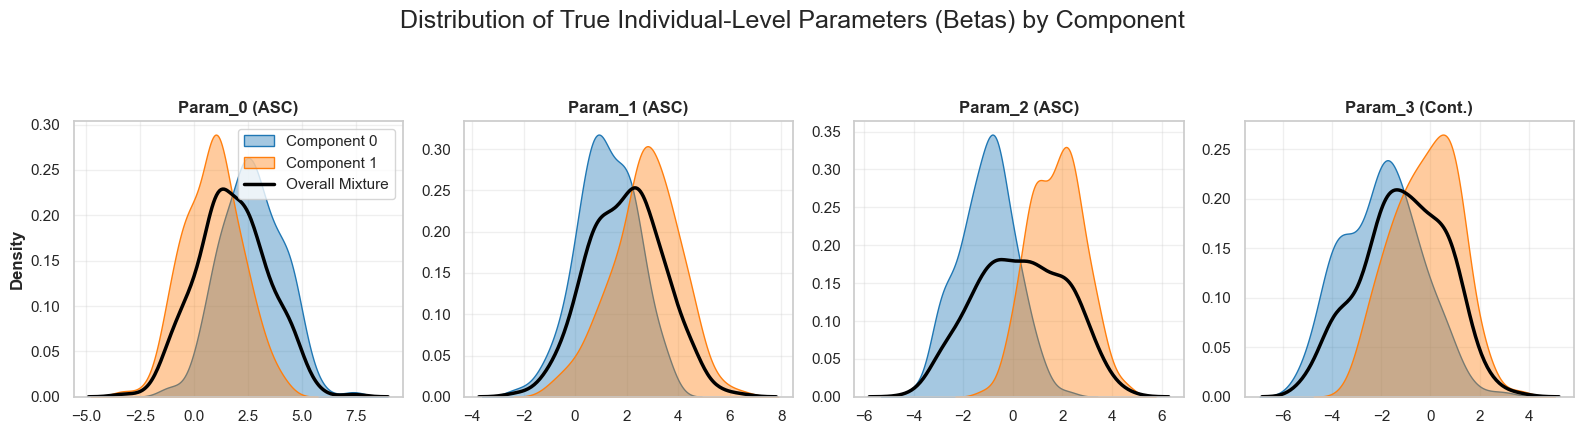

In [3]:
def plot_beta_mixture_distributions(betas, indicators, K, p_names):
    n_params = len(p_names)
    fig, axes = plt.subplots(1, n_params, figsize=(4 * n_params, 4))
    
    if n_params == 1:
        axes = [axes]
        
    colors = sns.color_palette("tab10", K) 
    
    for p in range(n_params):
        ax = axes[p]
        for k in range(K):
            comp_betas = betas[indicators == k, p]
            if len(comp_betas) > 1: 
                sns.kdeplot(
                    comp_betas, ax=ax, fill=True, color=colors[k], 
                    alpha=0.4, label=f"Component {k}"
                )
        
        sns.kdeplot(
            betas[:, p], ax=ax, color="black", linewidth=2.5, label="Overall Mixture"
        )
        
        ax.set_title(p_names[p], fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_ylabel("Density" if p == 0 else "", fontweight='bold')
        
        if p == 0:
            handles, labels = ax.get_legend_handles_labels()
            unique = [(h, l) for i, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:i]]
            ax.legend(*zip(*unique), loc='upper right')

    plt.suptitle("Distribution of True Individual-Level Parameters (Betas) by Component", fontsize=18, y=1.08)
    plt.tight_layout()
    plt.show()

print("\nPlotting Beta Mixture Distributions...")
param_names_labeled = [f"Param_{i} (ASC)" if i < (A-1) else f"Param_{i} (Cont.)" for i in range(P)]
plot_beta_mixture_distributions(
    betas=sim_data["TRUE_BETA"], 
    indicators=sim_data["TRUE_INDICATORS"], 
    K=sim_data["K"], 
    p_names=param_names_labeled
)

In [4]:
# ==============================================================================
# 2. MODEL BUILDING
# ==============================================================================
def make_wishart(df, scale_tril):
    return tfd.WishartTriL(
        df=df, scale_tril=scale_tril, input_output_cholesky=True, validate_args=False
    )

def make_mvn_precision(loc, precision_factor):
    return tfde.MultivariateNormalPrecisionFactorLinearOperator(
        loc=loc, precision_factor=tf.linalg.LinearOperatorLowerTriangular(precision_factor), validate_args=False
    )

def build_mixture_hmnl_model(data_dict, A_delta=0.01, a_mu=1.0):
    n_params = int(data_dict["n_params"])
    n_units  = int(data_dict["n_units"])
    K        = int(data_dict["K"])
    has_Z    = data_dict.get("Z") is not None

    nu = float(n_params + 3)
    V_inv = jnp.linalg.inv(nu * jnp.eye(n_params))
    Vinv_chol = jnp.linalg.cholesky(V_inv)
    Vinv_chol_K = jnp.broadcast_to(Vinv_chol[None], (K, n_params, n_params))

    alpha = jnp.ones(K) * 1.0 
    pvec = lsl.Var.new_param(
        value=jnp.ones(K) / K,
        distribution=lsl.Dist(tfd.Dirichlet, concentration=alpha),
        name="pvec"
    )
    pvec_latent = pvec.transform(tfb.SoftmaxCentered(), name="pvec_latent")

    sigma_inv_chol_k = lsl.Var.new_param(
        value=jnp.array(jnp.broadcast_to(jnp.eye(n_params)[None], (K, n_params, n_params))),
        distribution=lsl.Dist(
            make_wishart, df=jnp.full(K, nu), scale_tril=Vinv_chol_K
        ),
        name="sigma_inv_chol_k"
    )
    sigma_inv_chol_k_latent = sigma_inv_chol_k.transform(
        tfb.FillScaleTriL(), name="sigma_inv_chol_k_latent"
    )

    mu_prec_factor_k = lsl.Var.new_calc(
        lambda L: jnp.sqrt(a_mu) * L, L=sigma_inv_chol_k, name="mu_prec_factor_k"
    )

    mu_k = lsl.Var.new_param(
        value=jnp.zeros((K, n_params)),
        distribution=lsl.Dist(
            make_mvn_precision, loc=jnp.zeros(n_params), precision_factor=mu_prec_factor_k
        ),
        name="mu_k"
    )

    if has_Z:
        n_demos = data_dict["Z"].shape[1]
        Z_var = lsl.Var.new_obs(data_dict["Z"], name="Z_obs")
        Delta_prec_factor = jnp.sqrt(A_delta) * jnp.eye(n_params) 
        
        Delta = lsl.Var.new_param(
            value=jnp.zeros((n_demos, n_params)),
            distribution=lsl.Dist(
                make_mvn_precision, loc=jnp.zeros(n_params), precision_factor=Delta_prec_factor
            ),
            name="Delta"
        )
        z_delta = lsl.Var.new_calc(lambda z, d: z @ d, z=Z_var, d=Delta, name="z_delta")

    sigma_chol_k = lsl.Var.new_calc(
        lambda L: jax.vmap(
            lambda Lk: jnp.linalg.cholesky(jnp.linalg.inv(Lk @ Lk.T) + 1e-6 * jnp.eye(n_params))
        )(L),
        L=sigma_inv_chol_k,
        name="sigma_chol_k"
    )

    if has_Z:
        beta_loc = lsl.Var.new_calc(
            lambda zd, mu: zd[:, None, :] + mu[None, :, :],
            zd=z_delta, mu=mu_k, name="beta_loc"
        )
    else:
        beta_loc = lsl.Var.new_calc(
            lambda mu: jnp.broadcast_to(mu[None, :, :], (n_units, K, n_params)),
            mu=mu_k, name="beta_loc"
        )

    def make_beta_mixture(pvec, locs, scale_trils):
        return tfd.MixtureSameFamily(
            mixture_distribution=tfd.Categorical(probs=pvec),
            components_distribution=tfd.MultivariateNormalTriL(
                loc=locs, scale_tril=scale_trils[None]
            )
        )

    beta_i = lsl.Var.new_param(
        value=jnp.zeros((n_units, n_params)),
        distribution=lsl.Dist(
            make_beta_mixture, pvec=pvec, locs=beta_loc, scale_trils=sigma_chol_k
        ),
        name="beta_i"
    )

    X_var = lsl.Var.new_obs(data_dict["X"], name="X_obs")
    idx_var = lsl.Var.new_obs(data_dict["unit_idx"], name="idx_obs")

    beta_expanded = lsl.Var.new_calc(lambda b, idx: b[idx], b=beta_i, idx=idx_var, name="beta_expanded")
    logits = lsl.Var.new_calc(lambda x, b: jnp.einsum("nij,nj->ni", x, b), x=X_var, b=beta_expanded, name="logits")
    y_var = lsl.Var.new_obs(data_dict["y"], distribution=lsl.Dist(tfd.Categorical, logits=logits), name="y")

    return lsl.Model([y_var])

In [5]:
# ==============================================================================
# 3. MCMC INFERENCE
# ==============================================================================
def run_mixture_inference(model, data_dict, chains=4, warmup=1000, posterior=2000, seed=123):
    has_Z = data_dict.get("Z") is not None
    eb = gs.EngineBuilder(seed=seed, num_chains=chains)
    eb.set_model(gs.LieselInterface(model))
    eb.set_initial_values(model.state)

    eb.add_kernel(gs.NUTSKernel(["pvec_latent"]))
    eb.add_kernel(gs.NUTSKernel(["sigma_inv_chol_k_latent"], mm_diag=False))
    eb.add_kernel(gs.NUTSKernel(["mu_k"]))
    
    if has_Z:
        eb.add_kernel(gs.NUTSKernel(["Delta"]))
        
    eb.add_kernel(gs.NUTSKernel(["beta_i"]))
    eb.set_duration(warmup_duration=warmup, posterior_duration=posterior)

    print("Starting NUTS Sampling — Mixture of Normals HMNL...")
    engine = eb.build()
    engine.sample_all_epochs()

    return engine.get_results(), engine.get_results().get_posterior_samples()

print("Building Mixture of Normals HMNL Model...")
choice_data = sim_data
hmnl_model = build_mixture_hmnl_model(choice_data)

start_time = time.time()
mcmc_results, posterior_samples = run_mixture_inference(
    hmnl_model, choice_data, chains=4, warmup=1000, posterior=2000
)

formatted_time = str(datetime.timedelta(seconds=int(time.time() - start_time)))
print(f"Sampling finished in {formatted_time}")

Building Mixture of Normals HMNL Model...


c:\Users\ThinkPad\Desktop\Repositories\BDCM\liesel_project\.venv\Lib\site-packages\jax\_src\numpy\array_methods.py:122: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
liesel.goose.builder - WARNING - No jitter functions provided. The initial values won't be jittered
liesel.goose.engine - INFO - Initializing kernels...


Starting NUTS Sampling — Mixture of Normals HMNL...


liesel.goose.engine - INFO - Done
liesel.goose.engine - INFO - Starting epoch: FAST_ADAPTATION, 75 transitions, 25 jitted together
100%|██████████████████████████████████████████| 3/3 [00:41<00:00, 13.84s/chunk]
liesel.goose.engine - WARNING - Errors per chain for kernel_00: 1, 4, 7, 0 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_01: 5, 6, 8, 6 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_02: 1, 3, 4, 5 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_03: 1, 2, 1, 3 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_04: 2, 2, 2, 2 / 75 transitions
liesel.goose.engine - INFO - Finished epoch
liesel.goose.engine - INFO - Starting epoch: SLOW_ADAPTATION, 25 transitions, 25 jitted together
100%|█████████████████████████████████████████| 1/1 [00:00<00:00, 273.82chunk/s]
liesel.goose.engine - WARNING - Errors per chain for kernel_00: 1, 2, 1, 1 / 25 transitions
liesel.goose.e

Sampling finished in 0:29:19


In [6]:
# ==============================================================================
# 4. LABEL SWITCHING RESOLUTION (PRA)
# ==============================================================================
def pra(xi_star, xi_draws):
    m, K, J = xi_draws.shape
    perms = np.empty((m, K), dtype=int)
    relabeled = np.empty_like(xi_draws)

    for t in range(m):
        cost = np.sum((xi_star[:, None, :] - xi_draws[t, None, :, :]) ** 2, axis=-1)
        _, perms[t] = linear_sum_assignment(cost)
        relabeled[t] = xi_draws[t, perms[t], :]

    return perms, relabeled

def apply_permutations(draws, perms):
    m, K = perms.shape
    relabeled = np.empty_like(draws)
    for t in range(m):
        relabeled[t] = draws[t, perms[t]]
    return relabeled

def resolve_label_switching(samples_dict, pivot_chain_idx=0):
    print("\nStarting Pivotal Reordering Algorithm (PRA)...")
    mu = samples_dict["mu_k"] 
    n_chains, n_draws, K, n_params = mu.shape
    m = n_chains * n_draws
    
    mu_flat = mu.reshape(m, K, n_params)
    pivot_chain_mu = mu[pivot_chain_idx] 
    xi_star = np.mean(pivot_chain_mu, axis=0) 
    
    perms, relabeled_mu_flat = pra(xi_star, mu_flat)
    sorted_samples = samples_dict.copy()
    sorted_samples["mu_k"] = relabeled_mu_flat.reshape(n_chains, n_draws, K, n_params)
    
    sigma = samples_dict["sigma_inv_chol_k_latent"]
    sigma_shape = sigma.shape 
    sigma_flat = sigma.reshape(m, K, *sigma_shape[3:]) 
    relabeled_sigma_flat = apply_permutations(sigma_flat, perms)
    sorted_samples["sigma_inv_chol_k_latent"] = relabeled_sigma_flat.reshape(sigma_shape)
    
    pvec_latent = samples_dict["pvec_latent"]
    bijector_pvec = tfb.SoftmaxCentered()
    pvec_simplex = bijector_pvec.forward(pvec_latent) 
    
    pvec_flat = pvec_simplex.reshape(m, K)
    relabeled_pvec_flat = apply_permutations(pvec_flat, perms)
    sorted_samples["pvec"] = relabeled_pvec_flat.reshape(n_chains, n_draws, K)
    
    print("Label switching resolved! All chains are now aligned.")
    return sorted_samples

posterior_samples_sorted = resolve_label_switching(posterior_samples, pivot_chain_idx=0)


Starting Pivotal Reordering Algorithm (PRA)...
Label switching resolved! All chains are now aligned.



=== MCMC Convergence Summary ===


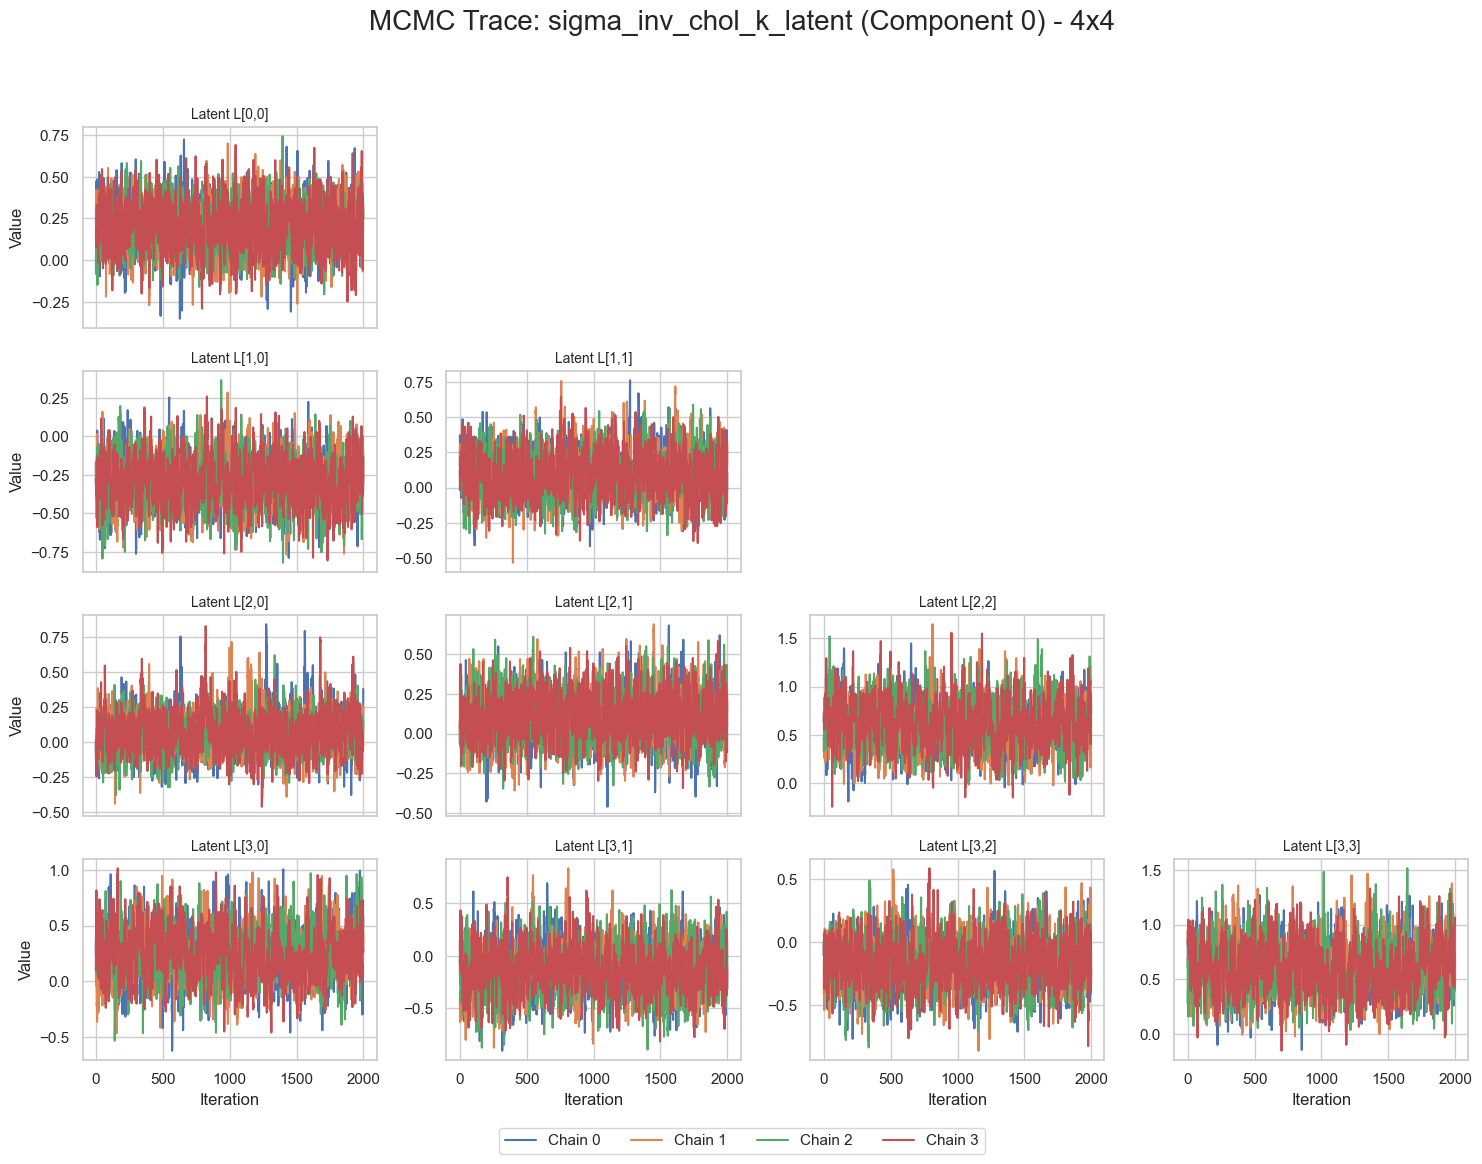

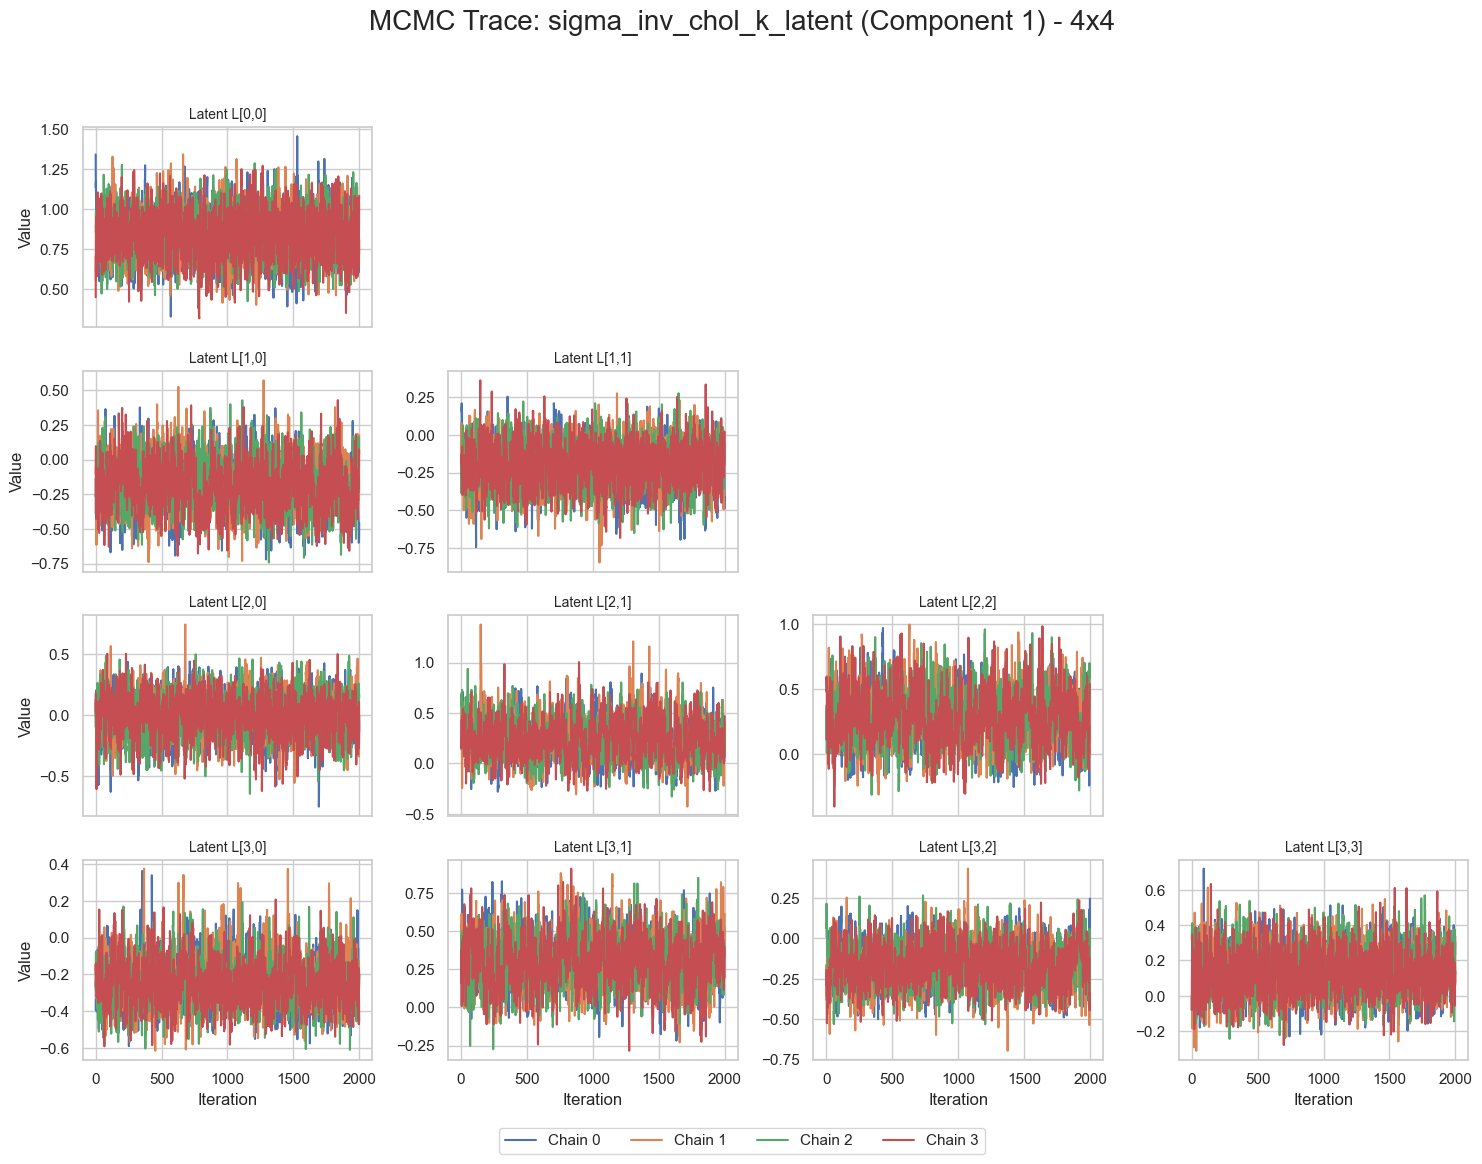

In [7]:
# ==============================================================================
# 5. MCMC DIAGNOSTICS & TRACE PLOTS
# ==============================================================================
print("\n=== MCMC Convergence Summary ===")
summary = gs.Summary(mcmc_results)

def plot_cholesky_traces(samples_dict, n_params, k_idx=0, param_name="sigma_inv_chol_k_latent", figsize=(15, 12)):
    latent_samples = samples_dict[param_name][:, :, k_idx, :]
    n_chains, n_draws, n_latent = latent_samples.shape

    fig, axes = plt.subplots(n_params, n_params, figsize=figsize, sharex=True, sharey=False)
    if n_params == 1:
        axes = np.array([[axes]])

    latent_idx = 0
    for i in range(n_params):        
        for j in range(n_params):    
            ax = axes[i, j]
            if i >= j and latent_idx < n_latent:
                for chain in range(n_chains):
                    ax.plot(latent_samples[chain, :, latent_idx], label=f"Chain {chain}")
                ax.set_title(f"Latent L[{i},{j}]", fontsize=10)
                latent_idx += 1
            else:
                ax.axis('off')
            
            ax.grid(True)
            if i == n_params - 1 or (i >= j and i + 1 < n_params and i + 1 < j): 
                ax.set_xlabel("Iteration")
            if j == 0:
                ax.set_ylabel("Value")

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=n_chains, bbox_to_anchor=(0.5, 0.02))
    plt.suptitle(f"MCMC Trace: {param_name} (Component {k_idx}) - {n_params}x{n_params}", fontsize=20)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

for k in range(K):
    plot_cholesky_traces(posterior_samples_sorted, n_params=P, k_idx=k)


Recovering Covariance Matrices (Sigma_k) from SORTED samples...


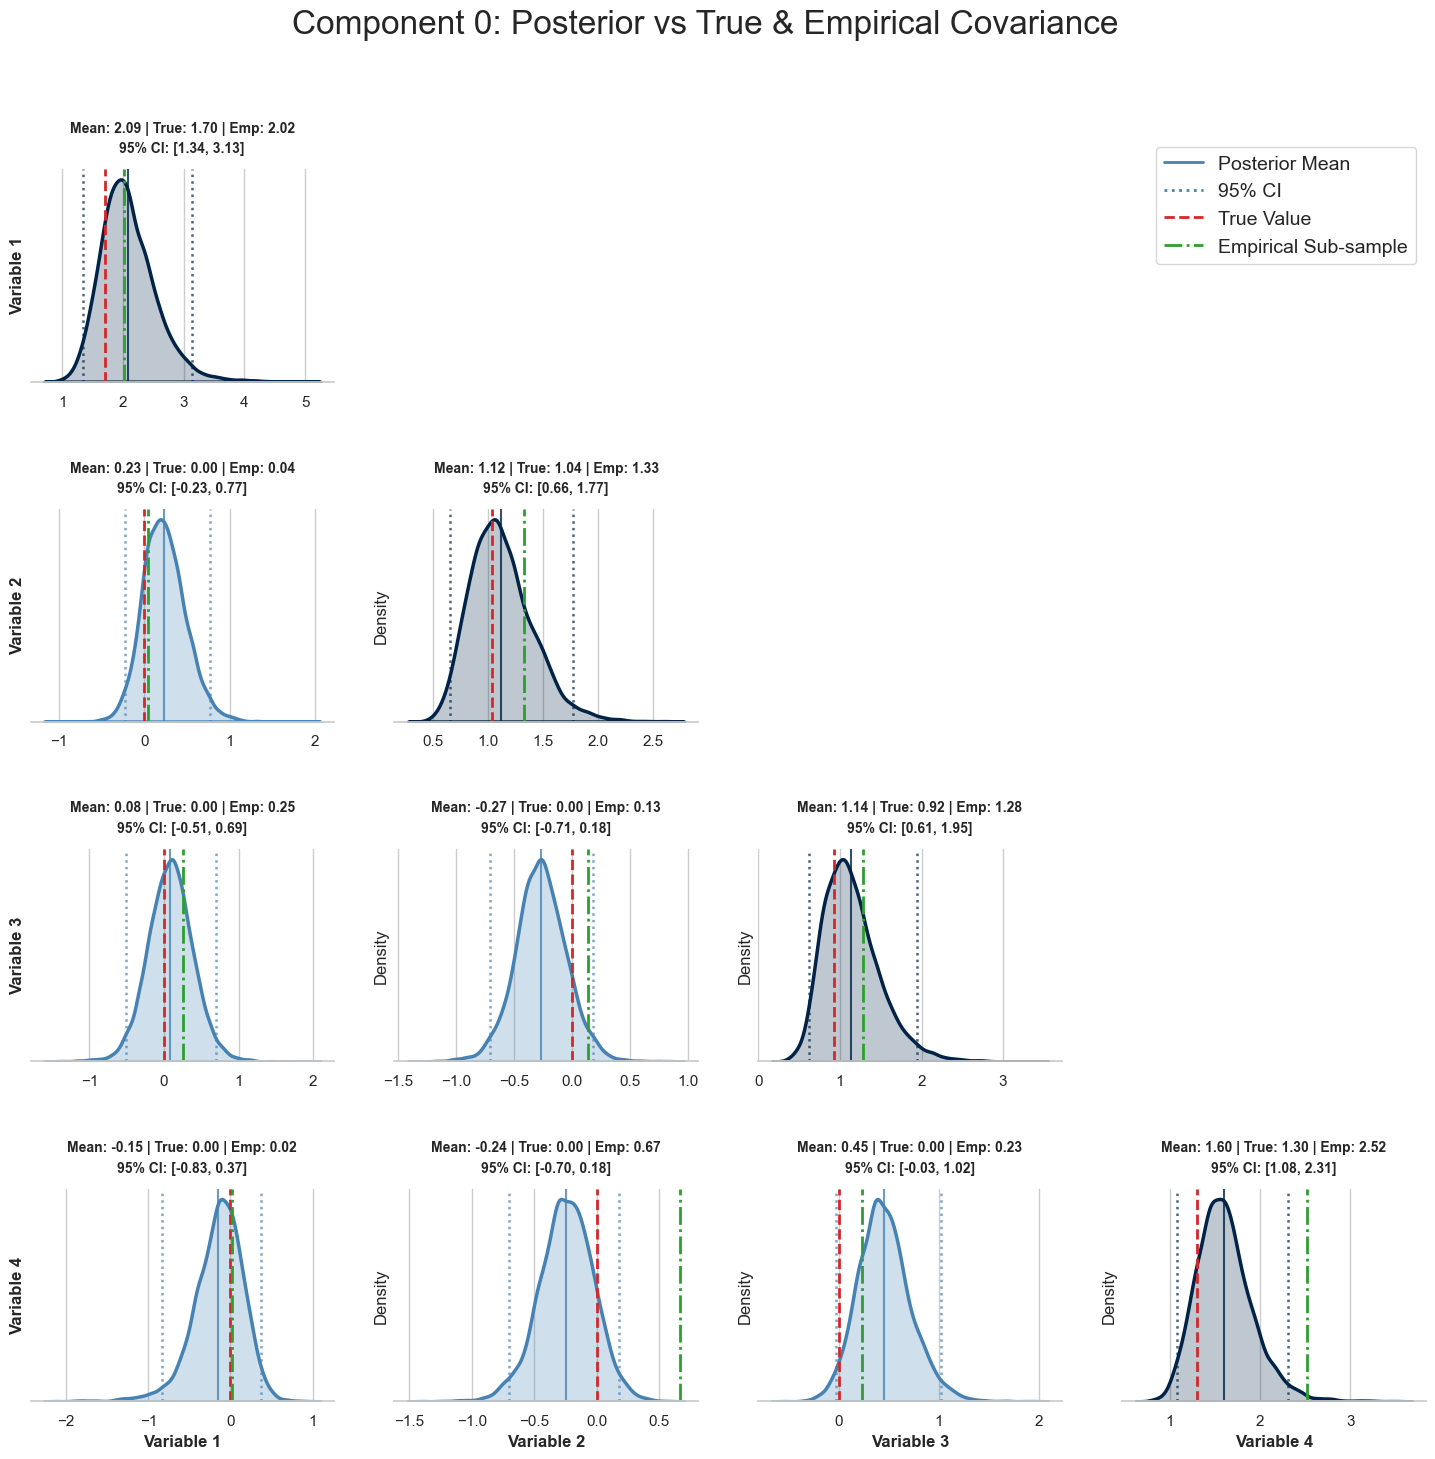

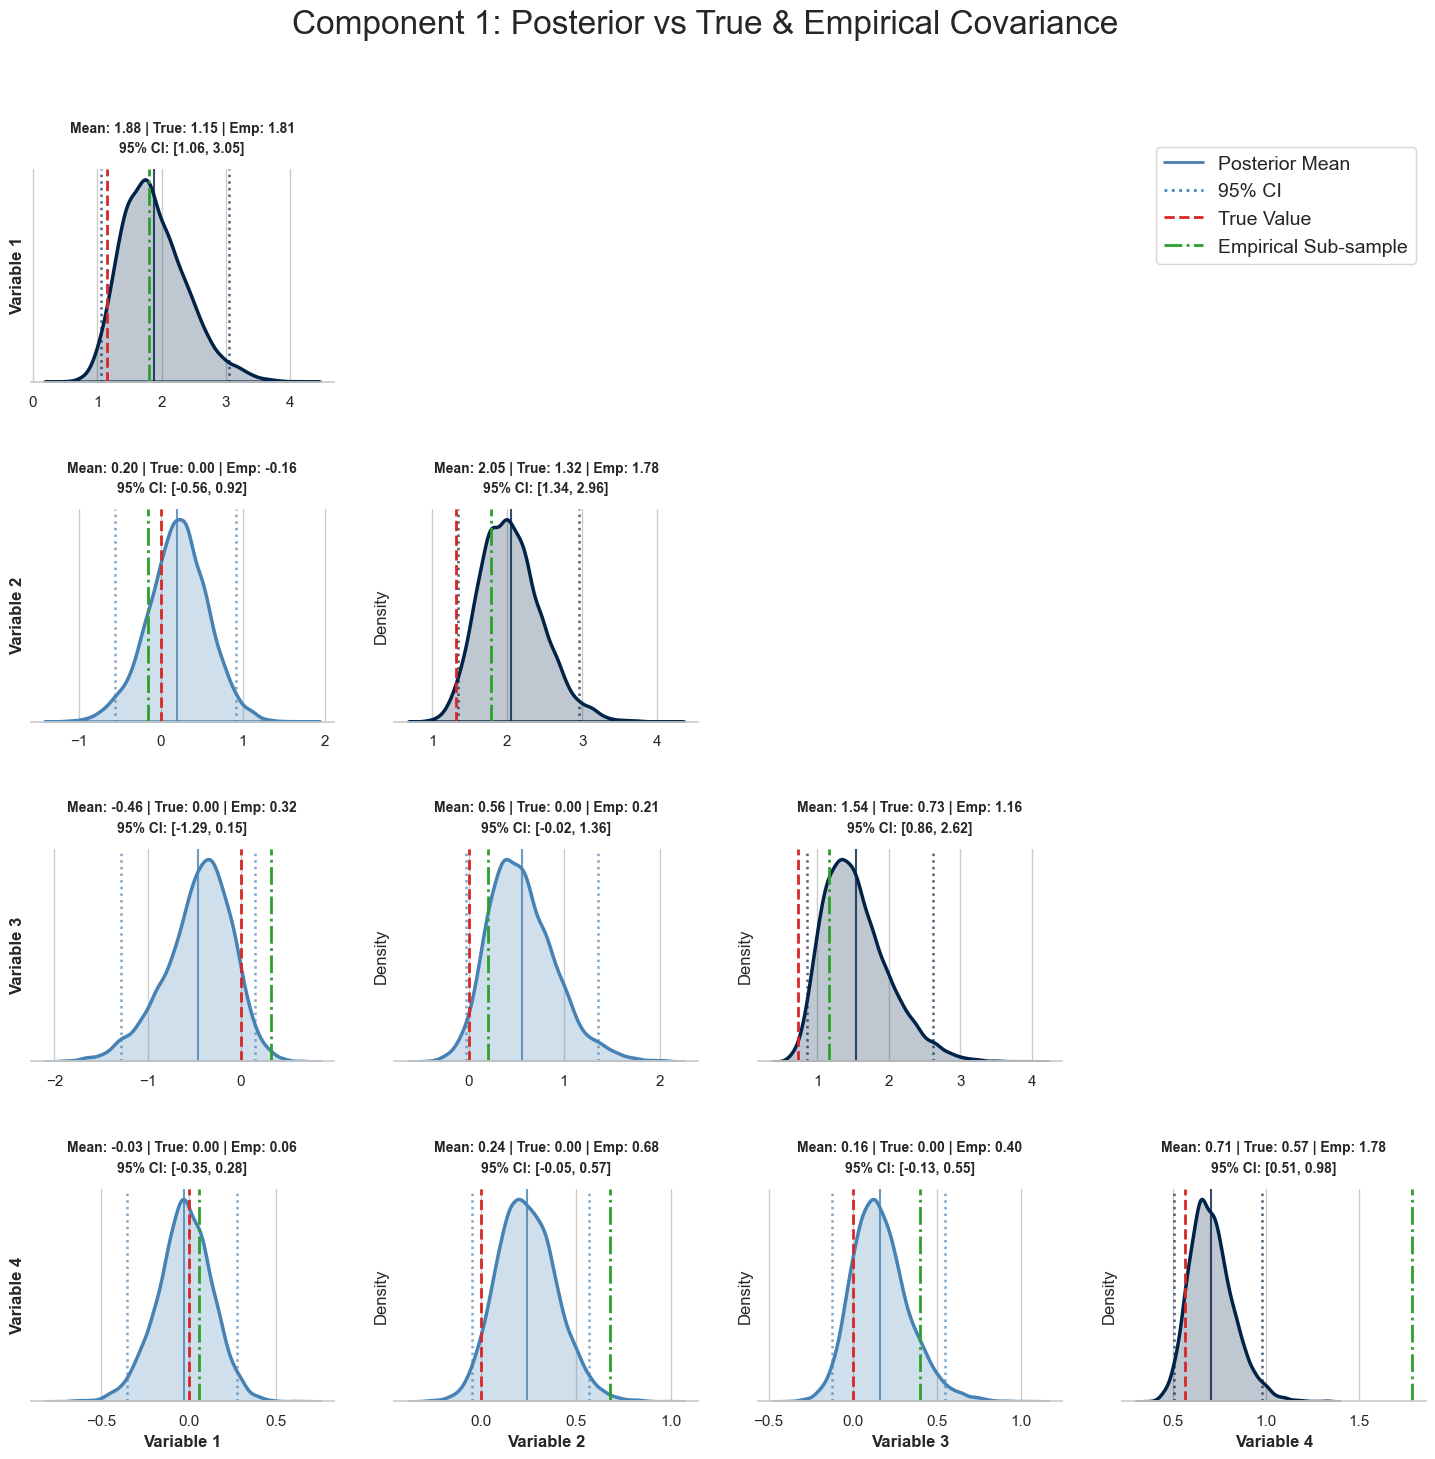

In [8]:
# ==============================================================================
# 6. COVARIANCE RECOVERY
# ==============================================================================
print("\nRecovering Covariance Matrices (Sigma_k) from SORTED samples...")
bijector_tril = tfb.FillScaleTriL()

def latent_to_sigma(latent_vec):
    L = bijector_tril.forward(latent_vec)
    precision_mat = L @ L.T
    return jnp.linalg.inv(precision_mat)

v_latent_to_sigma = jax.vmap(jax.vmap(jax.vmap(latent_to_sigma)))

latent_samples_sorted = posterior_samples_sorted["sigma_inv_chol_k_latent"]
sigma_samples_sorted = v_latent_to_sigma(latent_samples_sorted) 

def plot_final_covariance_complete(samples, true_matrix=None, empirical_matrix=None, component_idx=0):
    n_dim = samples.shape[-1]
    fig, axes = plt.subplots(n_dim, n_dim, figsize=(18, 16))
    flattened_samples = samples.reshape(-1, n_dim, n_dim)
    
    diag_color = "#002347"  
    off_diag_color = "#4682B4"  
    true_val_color = "#D62728"  
    emp_val_color = "#2CA02C"  

    for i in range(n_dim):
        for j in range(n_dim):
            ax = axes[i, j]
            if j > i:
                ax.axis('off') 
                continue
            
            data_vec = flattened_samples[:, i, j]
            current_color = diag_color if (i == j) else off_diag_color
            post_mean = np.mean(data_vec)
            ci_low, ci_high = np.percentile(data_vec, [2.5, 97.5])
            
            sns.kdeplot(data_vec, ax=ax, fill=True, color=current_color, alpha=0.25, lw=2.5)
            ax.axvline(post_mean, color=current_color, linestyle="-", lw=1.5, alpha=0.8)
            ax.axvline(ci_low, color=current_color, linestyle=":", lw=1.8, alpha=0.7)
            ax.axvline(ci_high, color=current_color, linestyle=":", lw=1.8, alpha=0.7)
            
            title_parts = [f"Mean: {post_mean:.2f}"]
            if true_matrix is not None:
                ax.axvline(true_matrix[i, j], color=true_val_color, linestyle="--", lw=2)
                title_parts.append(f"True: {true_matrix[i, j]:.2f}")
            if empirical_matrix is not None:
                ax.axvline(empirical_matrix[i, j], color=emp_val_color, linestyle="-.", lw=2)
                title_parts.append(f"Emp: {empirical_matrix[i, j]:.2f}")

            title_str = f"{' | '.join(title_parts)}\n95% CI: [{ci_low:.2f}, {ci_high:.2f}]"
            ax.set_title(title_str, fontsize=10, pad=12, linespacing=1.6, fontweight='bold')
            ax.set_yticks([])
            sns.despine(ax=ax, left=True)
            
            if i == n_dim - 1:
                ax.set_xlabel(f"Variable {j+1}", fontsize=12, fontweight='bold')
            if j == 0:
                ax.set_ylabel(f"Variable {i+1}", fontsize=12, fontweight='bold')

    legend_elements = [
        Line2D([0], [0], color=off_diag_color, linestyle='-', lw=2, label='Posterior Mean'),
        Line2D([0], [0], color=off_diag_color, linestyle=':', lw=2, label='95% CI'),
        Line2D([0], [0], color=true_val_color, linestyle='--', lw=2, label='True Value'),
        Line2D([0], [0], color=emp_val_color, linestyle='-.', lw=2, label='Empirical Sub-sample')
    ]
    
    fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.9, 0.9), fontsize=14, frameon=True)
    plt.suptitle(f"Component {component_idx}: Posterior vs True & Empirical Covariance", fontsize=24, y=0.98)
    plt.subplots_adjust(hspace=0.6, wspace=0.2)
    plt.show()

for k in range(K):
    comp_mask = choice_data["TRUE_INDICATORS"] == k
    comp_betas = choice_data["TRUE_BETA"][comp_mask]
    empirical_sigma_k = jnp.cov(comp_betas, rowvar=False) if len(comp_betas) > 1 else None

    plot_final_covariance_complete(
        samples=sigma_samples_sorted[:, :, k, :, :], 
        true_matrix=choice_data["TRUE_SIGMA_K"][k], 
        empirical_matrix=empirical_sigma_k,
        component_idx=k
    )


=== Detailed Delta Parameter Diagnostics (Goose Style) ===


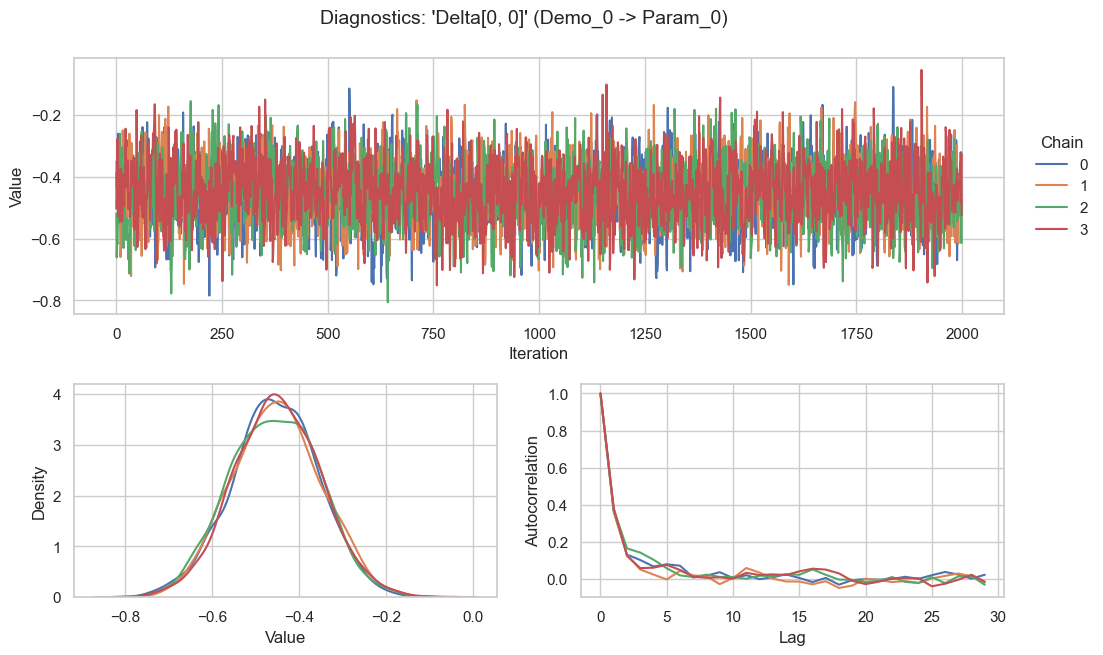

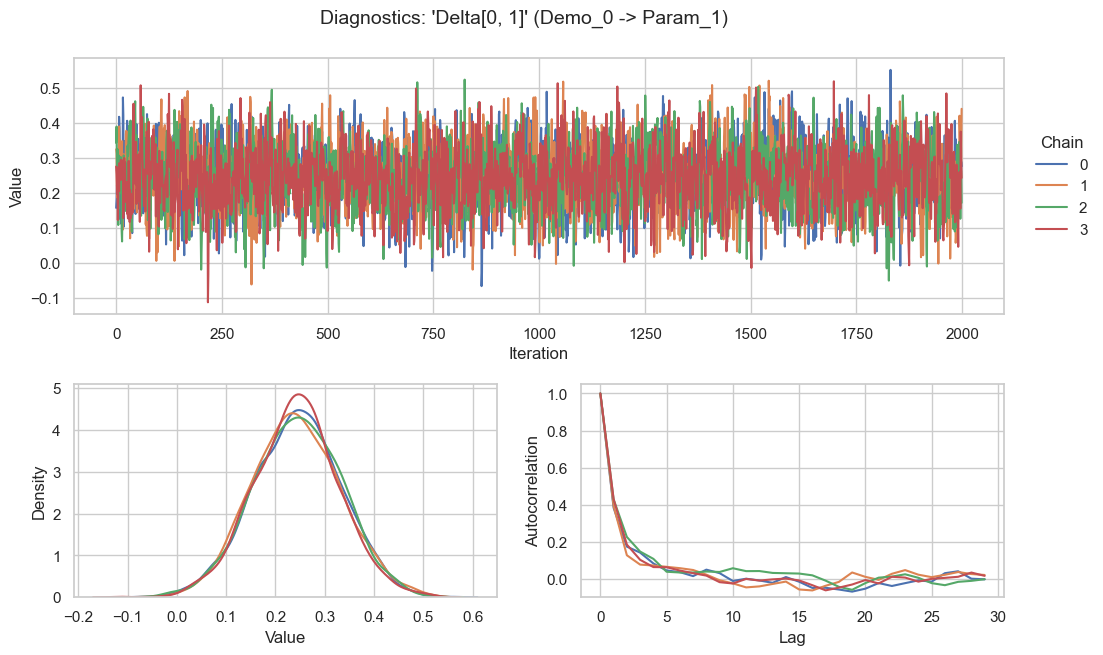

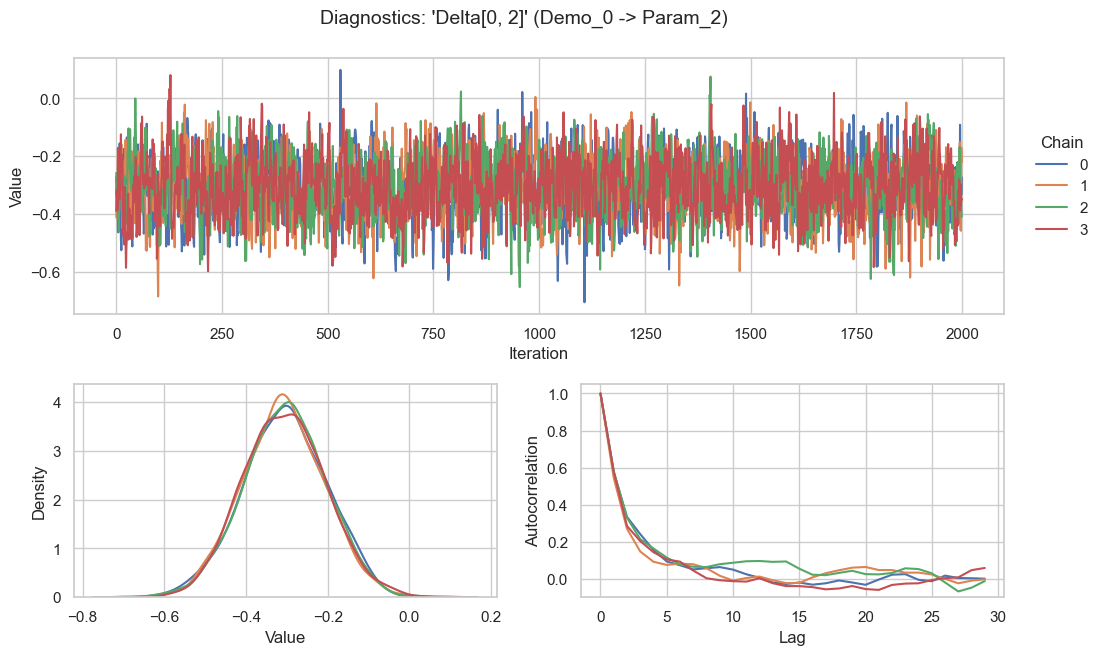

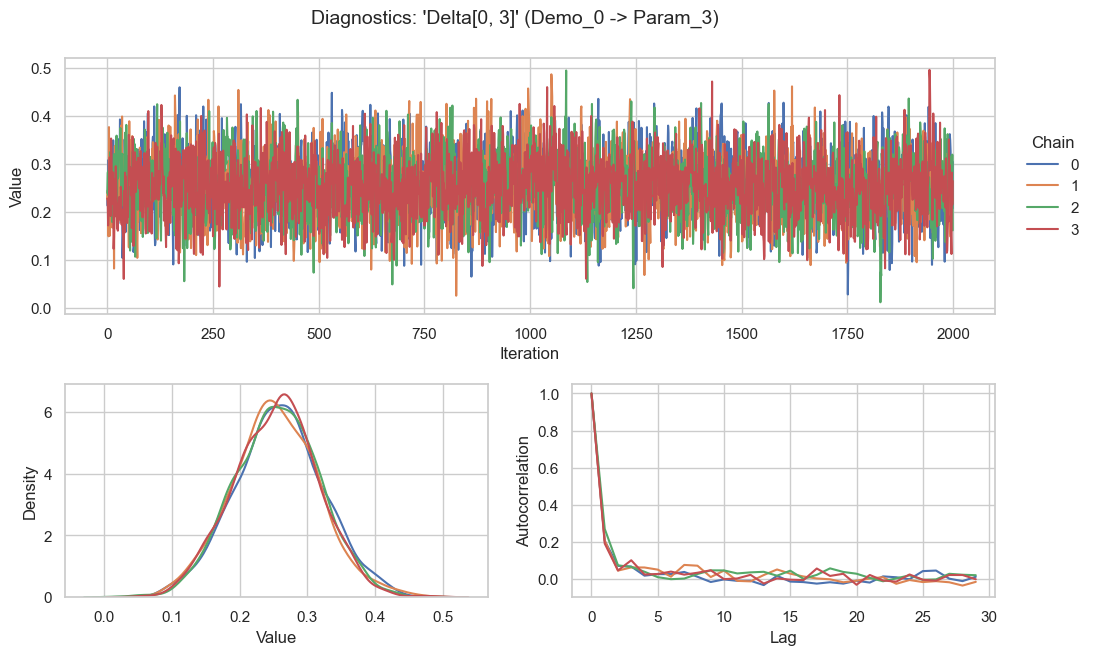

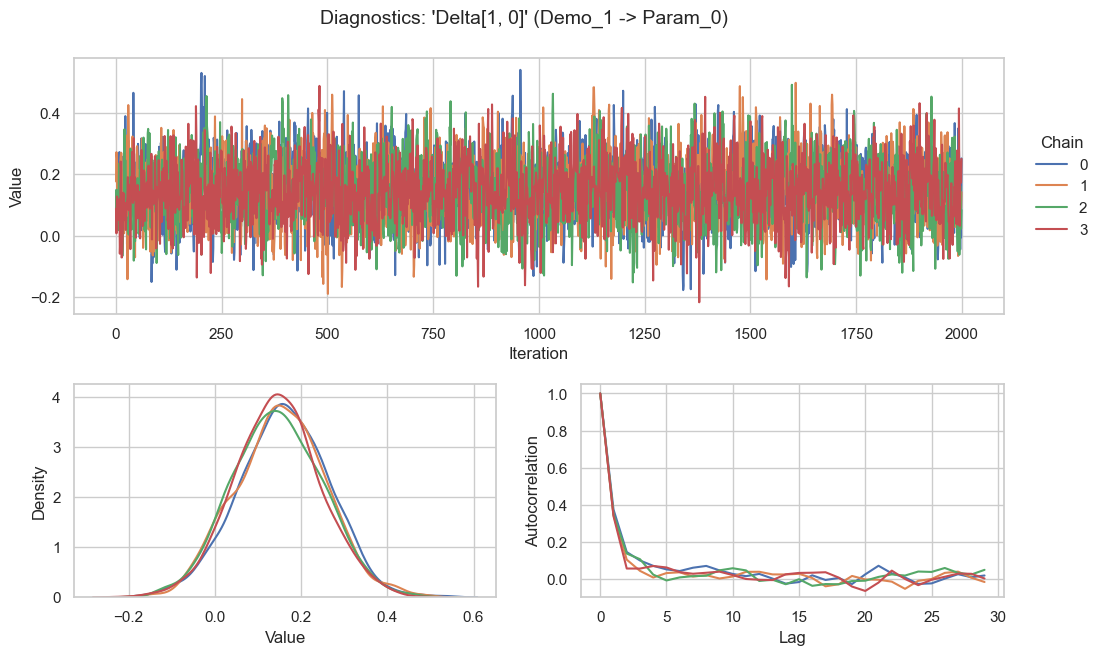

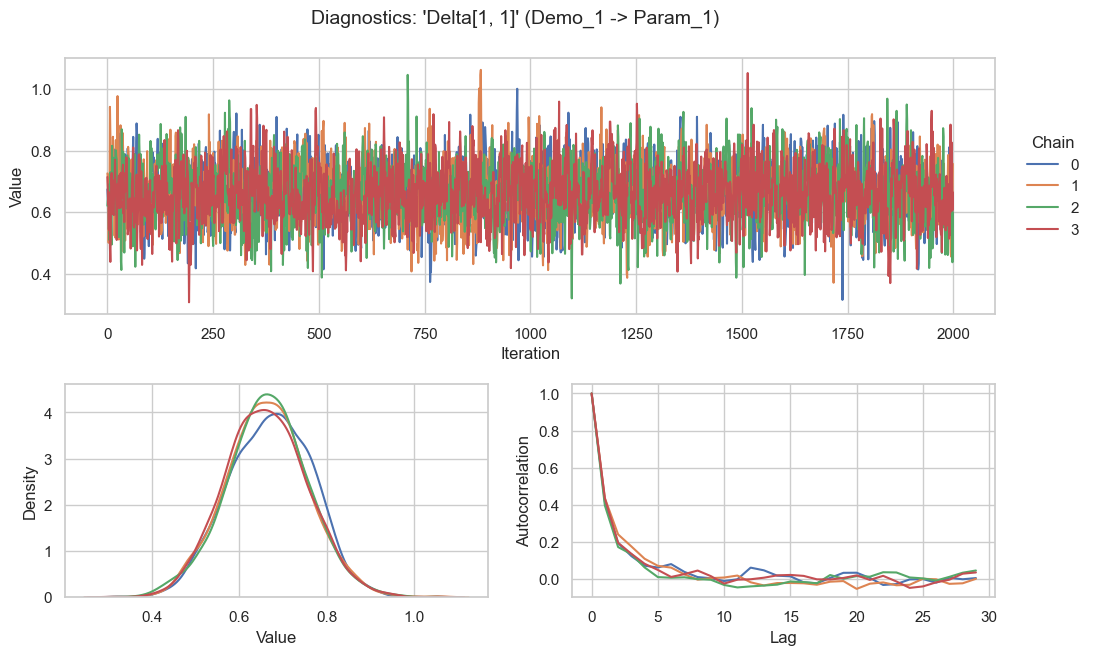

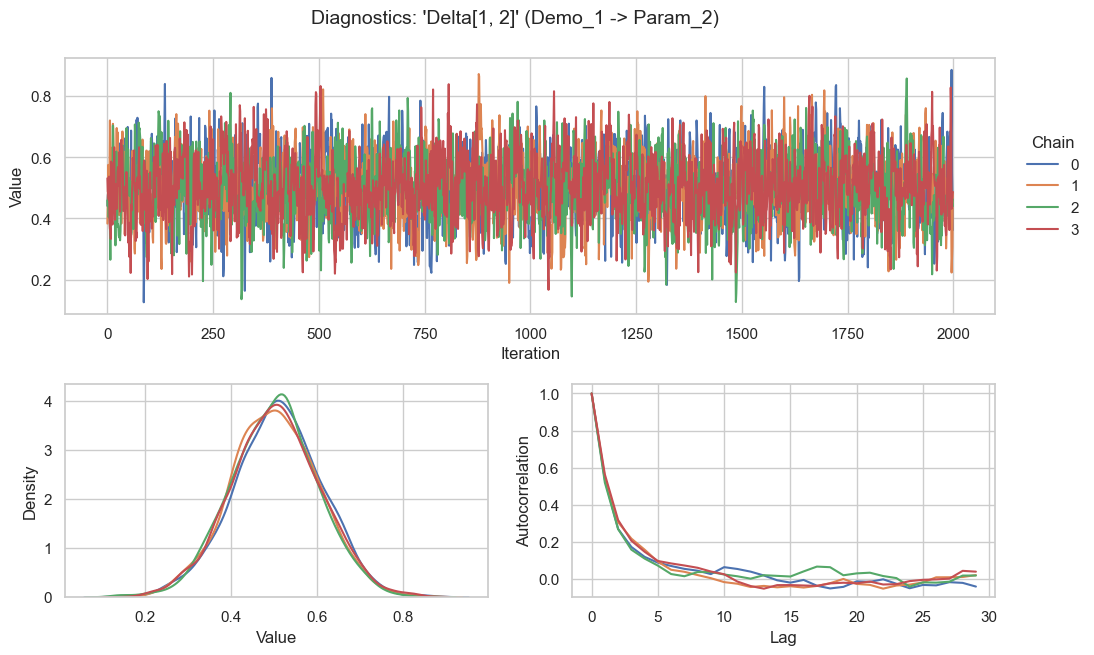

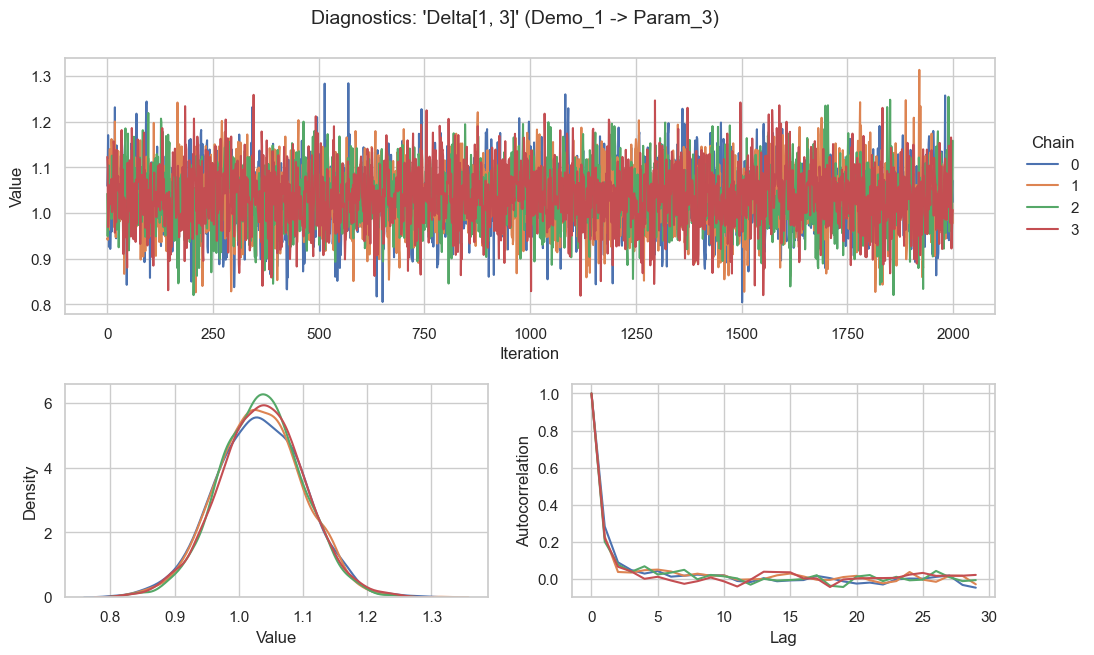

In [9]:
# ==============================================================================
# 7. GOOSE-STYLE DIAGNOSTICS
# ==============================================================================
def compute_acf(x, nlags=30):
    x_centered = x - np.mean(x)
    norm = np.sum(x_centered**2)
    if norm == 0: return np.zeros(nlags)
    acf = np.correlate(x_centered, x_centered, mode='full')
    return (acf[acf.size // 2:] / norm)[:nlags]

def plot_goose_style_diagnostics(delta_array, demo_idx, param_idx, demo_name, param_name, n_lags=30):
    n_chains = delta_array.shape[0]
    fig = plt.figure(figsize=(12, 7))
    fig.suptitle(f"Diagnostics: 'Delta[{demo_idx}, {param_idx}]' ({demo_name} -> {param_name})", fontsize=14, y=0.95)
    gs_layout = gridspec.GridSpec(2, 2, height_ratios=[1.2, 1], hspace=0.3, wspace=0.2)
    
    ax_trace = fig.add_subplot(gs_layout[0, :])
    for chain in range(n_chains):
        ax_trace.plot(delta_array[chain, :, demo_idx, param_idx], label=f"{chain}")
    
    ax_trace.set_xlabel("Iteration")
    ax_trace.set_ylabel("Value")
    ax_trace.grid(True, alpha=1)
    ax_trace.legend(title="Chain", loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
    
    ax_dens = fig.add_subplot(gs_layout[1, 0])
    for chain in range(n_chains):
        sns.kdeplot(delta_array[chain, :, demo_idx, param_idx], ax=ax_dens, fill=False)
    ax_dens.set_xlabel("Value")
    ax_dens.set_ylabel("Density")
    ax_dens.grid(True)
    
    ax_acf = fig.add_subplot(gs_layout[1, 1])
    for chain in range(n_chains):
        ax_acf.plot(compute_acf(delta_array[chain, :, demo_idx, param_idx], nlags=n_lags), alpha=1)
    ax_acf.set_xlabel("Lag")
    ax_acf.set_ylabel("Autocorrelation")
    ax_acf.set_ylim(-0.1, 1.05)
    ax_acf.grid(True)
    plt.show()

print("\n=== Detailed Delta Parameter Diagnostics (Goose Style) ===")
raw_delta_samples = posterior_samples_sorted["Delta"]
for i in range(D):
    for j in range(P):
        plot_goose_style_diagnostics(
            raw_delta_samples, demo_idx=i, param_idx=j, 
            demo_name=f"Demo_{i}", param_name=f"Param_{j}"
        )


=== Global Parameters (Baseline Means) Summary Tables ===

--- Sorted MCMC Component 0 (Mapped to True Component 0) ---


,True_Value,Posterior_Mean,Diff_Abs,Posterior_Std
Parameter,,,,
Param_0,2.5266,2.5785,0.0519,0.1941
Param_1,1.0739,1.1261,0.0522,0.1604
Param_2,-1.2251,-1.1739,0.0511,0.2146
Param_3,-2.0395,-2.0072,0.0323,0.2271



--- Sorted MCMC Component 1 (Mapped to True Component 1) ---


,True_Value,Posterior_Mean,Diff_Abs,Posterior_Std
Parameter,,,,
Param_0,1.0687,1.1406,0.0718,0.2076
Param_1,2.6586,2.6961,0.0375,0.2142
Param_2,1.7922,1.5967,0.1955,0.2447
Param_3,-0.2600,-0.3186,0.0586,0.1004



=== True distribution of Delta (Ground Truth) ===


...


=== Posterior distribution of Delta ===


,Param_0,Param_1,Param_2,Param_3
Demo_0,-0.45 (0.10),0.24 (0.09),-0.31 (0.10),0.26 (0.06)
Demo_1,0.15 (0.10),0.67 (0.09),0.50 (0.10),1.03 (0.07)



=== ABSOLUTE DIFFERENCE in Delta (|True - Posterior|) ===


,Param_0,Param_1,Param_2,Param_3
Demo_0,0.128,0.074,0.142,0.039
Demo_1,0.291,0.158,0.046,0.025



Plotting Delta Distributions...


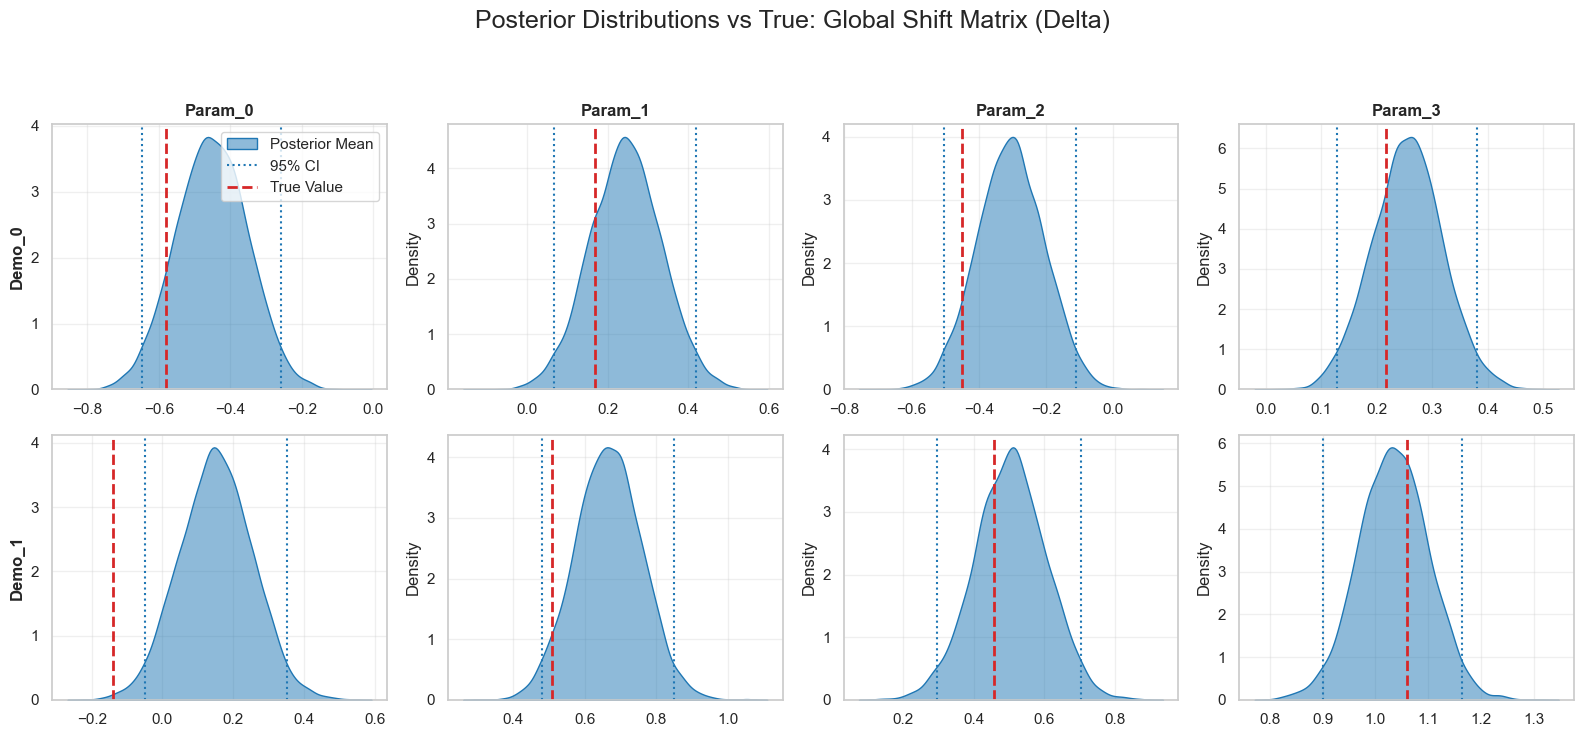

In [10]:
# ==============================================================================
# 8. GLOBAL PARAMETERS: BASELINE MEANS & DELTA
# ==============================================================================
def create_summary_table(t_mu, post_mu, p_names):
    return pd.DataFrame({
        'Parameter': p_names,
        'True_Value': t_mu,
        'Posterior_Mean': post_mu.mean(axis=0),
        'Diff_Abs': np.abs(t_mu - post_mu.mean(axis=0)),
        'Posterior_Std': post_mu.std(axis=0)
    }).round(4).set_index("Parameter")

print("\n=== Global Parameters (Baseline Means) Summary Tables ===")
mu_samples_sorted = posterior_samples_sorted["mu_k"] 
mu_samples_sorted_flat = mu_samples_sorted.reshape(-1, K, P) 

# Map sorted MCMC components to the True component indices using distance
sorted_mu_mean = mu_samples_sorted_flat.mean(axis=0)
cost_matrix = np.sum((sorted_mu_mean[:, None, :] - choice_data["TRUE_MU_K"][None, :, :]) ** 2, axis=-1)
_, true_mapping = linear_sum_assignment(cost_matrix)

for k in range(K):
    true_k = true_mapping[k]
    print(f"\n--- Sorted MCMC Component {k} (Mapped to True Component {true_k}) ---")
    display(create_summary_table(
        t_mu=choice_data["TRUE_MU_K"][true_k], 
        post_mu=mu_samples_sorted_flat[:, k, :], 
        p_names=param_names
    ))

def generate_delta_table(delta_draws, p_names, d_names):
    mean, std = np.mean(delta_draws, axis=0), np.std(delta_draws, axis=0)
    df = pd.DataFrame(index=d_names, columns=p_names)
    for i in range(len(d_names)):
        for j in range(len(p_names)):
            df.iloc[i, j] = f"{mean[i, j]:.2f} ({std[i, j]:.2f})"
    return df

def generate_delta_diff_table(t_delta, l_delta, p_names, d_names):
    diff_mean = np.abs(t_delta - np.mean(l_delta, axis=0))
    df = pd.DataFrame(index=d_names, columns=p_names)
    for i in range(len(d_names)):
        for j in range(len(p_names)):
            df.iloc[i, j] = f"{diff_mean[i, j]:.3f}"
    return df

print("\n=== True distribution of Delta (Ground Truth) ===")
display(pd.DataFrame(choice_data["TRUE_DELTA"], index=demo_names, columns=param_names))

delta_samples_sorted = posterior_samples_sorted["Delta"].reshape(-1, D, P)

print("\n=== Posterior distribution of Delta ===")
display(generate_delta_table(delta_samples_sorted, param_names, demo_names))

print("\n=== ABSOLUTE DIFFERENCE in Delta (|True - Posterior|) ===")
display(generate_delta_diff_table(choice_data["TRUE_DELTA"], delta_samples_sorted, param_names, demo_names))


def plot_delta_distributions(delta_samples, t_delta, p_names, d_names):
    n_demos, n_params = len(d_names), len(p_names)
    fig, axes = plt.subplots(n_demos, n_params, figsize=(4*n_params, 3.5*n_demos))
    
    for d in range(n_demos):
        for p in range(n_params):
            ax = axes[d, p] if n_demos > 1 else axes[p]
            samples, t_val = delta_samples[:, d, p], t_delta[d, p]
            ci_low, ci_high = np.percentile(samples, [2.5, 97.5])
            
            sns.kdeplot(samples, ax=ax, fill=True, color="#1f77b4", alpha=0.5, label="Posterior Mean")
            ax.axvline(ci_low, color="#1f77b4", linestyle=":", lw=1.5, label="95% CI")
            ax.axvline(ci_high, color="#1f77b4", linestyle=":", lw=1.5)
            ax.axvline(t_val, color="#D62728", linestyle="--", lw=2, label="True Value")
            
            if d == 0: ax.set_title(p_names[p], fontweight='bold')
            if p == 0: ax.set_ylabel(d_names[d], fontweight='bold')
            ax.grid(True, alpha=0.3)
            
            if d == 0 and p == 0:
                handles, labels = ax.get_legend_handles_labels()
                unique = [(h, l) for i, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:i]]
                ax.legend(*zip(*unique), loc='upper right')

    plt.suptitle("Posterior Distributions vs True: Global Shift Matrix (Delta)", fontsize=18, y=1.05)
    plt.tight_layout()
    plt.show()

print("\nPlotting Delta Distributions...")
plot_delta_distributions(delta_samples_sorted, choice_data["TRUE_DELTA"], param_names, demo_names)

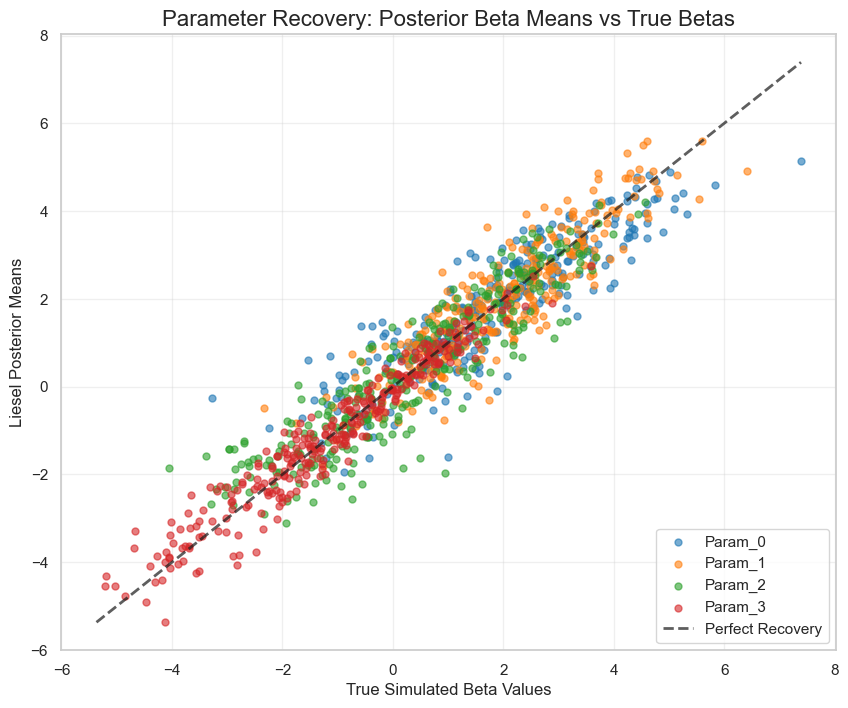


Plotting Household-Level Distributions...


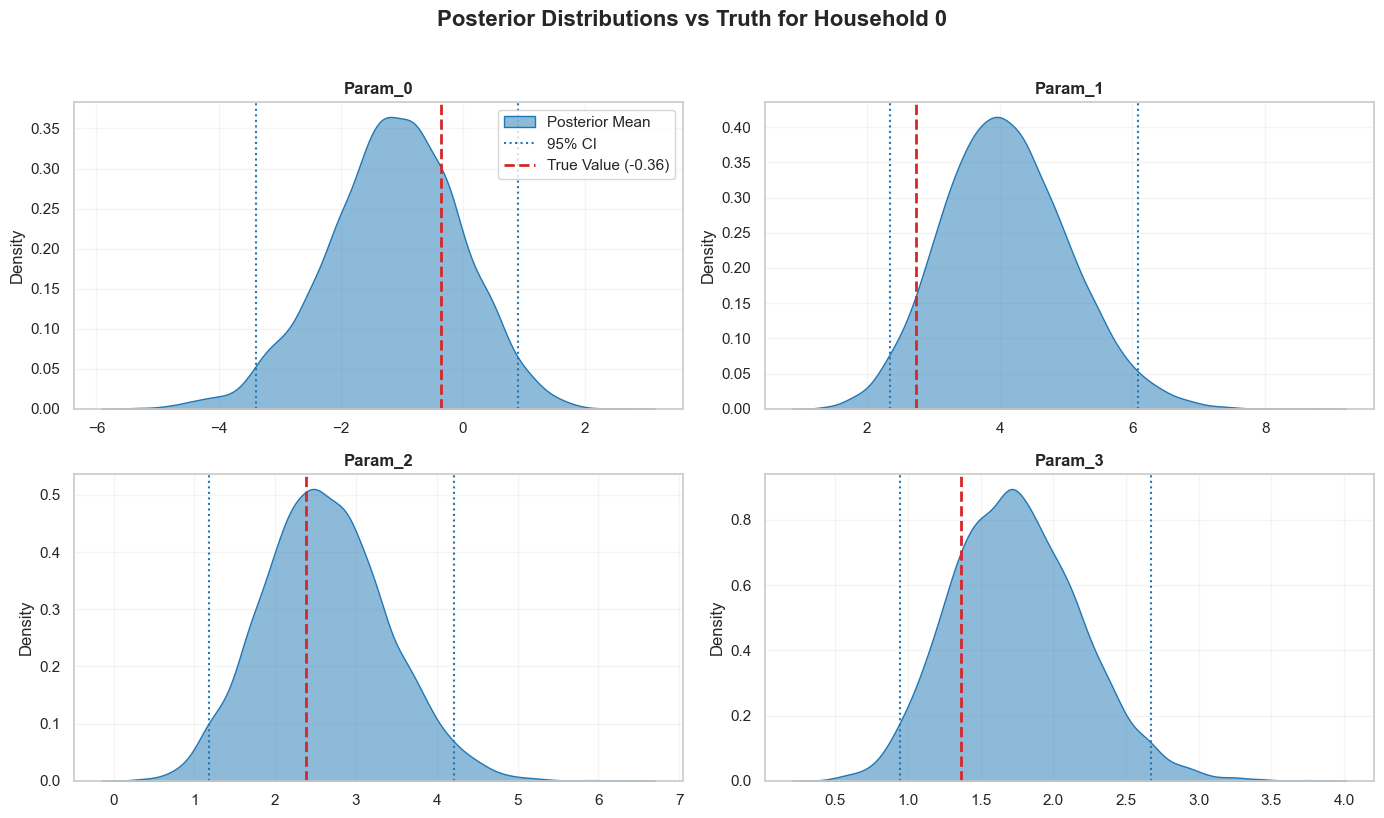

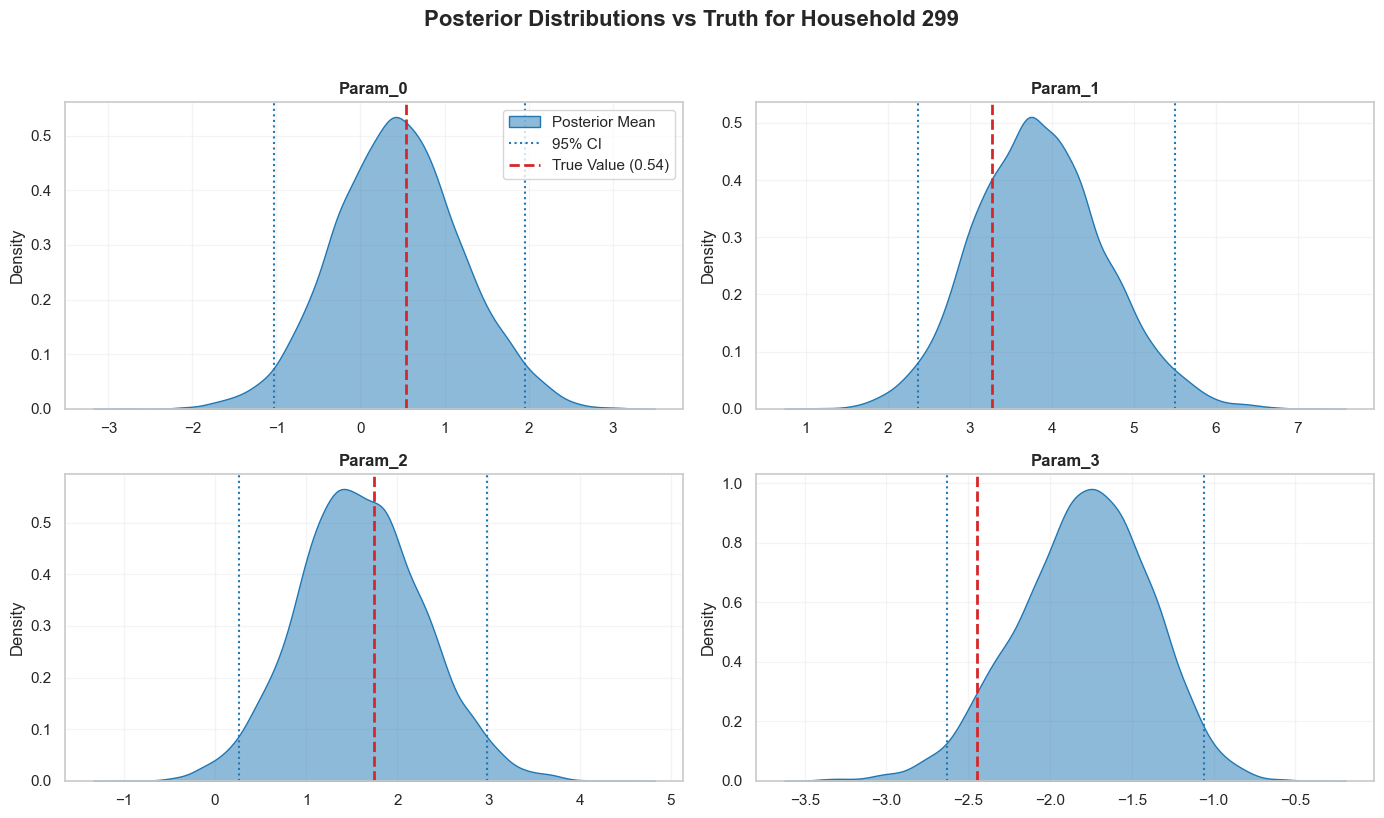

In [11]:
# ==============================================================================
# 9. HOUSEHOLD HETEROGENEITY (BETAS)
# ==============================================================================
n_chains, n_draws, n_units, n_params = posterior_samples_sorted["beta_i"].shape
liesel_beta_full = posterior_samples_sorted["beta_i"].reshape(-1, n_units, n_params)
true_betas_full = choice_data["TRUE_BETA"]

l_beta_means = np.mean(liesel_beta_full, axis=0)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'][:n_params]

for i, param in enumerate(param_names):
    ax.scatter(true_betas_full[:, i], l_beta_means[:, i], alpha=0.6, s=25, label=param, color=colors[i])

min_val = min(true_betas_full.min(), l_beta_means.min())
max_val = max(true_betas_full.max(), l_beta_means.max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, alpha=0.7, label='Perfect Recovery')

ax.set_title("Parameter Recovery: Posterior Beta Means vs True Betas", fontsize=16)
ax.set_xlabel("True Simulated Beta Values", fontsize=12)
ax.set_ylabel("Liesel Posterior Means", fontsize=12)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.show()

def plot_beta_distributions(samples, true_vals, p_names, title_prefix, color_l="#1f77b4", color_t="#d62728"):
    cols = 2
    rows = int(np.ceil(len(p_names) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))
    if len(p_names) == 1: axes = np.array([axes])
    
    for i, (ax, param) in enumerate(zip(axes.flatten(), p_names)):
        if i >= len(p_names):
            ax.axis('off')
            continue
            
        l_vals, t_val = samples[:, i], true_vals[i]
        ci_low, ci_high = np.percentile(l_vals, [2.5, 97.5])
        
        sns.kdeplot(l_vals, ax=ax, fill=True, color=color_l, alpha=0.5, label="Posterior Mean")
        ax.axvline(ci_low, color=color_l, linestyle=":", lw=1.5, label="95% CI")
        ax.axvline(ci_high, color=color_l, linestyle=":", lw=1.5)
        ax.axvline(t_val, color=color_t, linestyle="--", lw=2, label=f"True Value ({t_val:.2f})")
        
        ax.set_title(param, fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.2)
        
        if i == 0: 
            handles, labels = ax.get_legend_handles_labels()
            unique = [(h, l) for j, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:j]]
            ax.legend(*zip(*unique), loc="upper right")
            
    plt.suptitle(title_prefix, y=1.02, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("\nPlotting Household-Level Distributions...")
plot_beta_distributions(
    liesel_beta_full[:, 0, :], true_betas_full[0, :], param_names, 
    "Posterior Distributions vs Truth for Household 0"
)

plot_beta_distributions(
    liesel_beta_full[:, -1, :], true_betas_full[-1, :], param_names, 
    f"Posterior Distributions vs Truth for Household {n_units-1}"
)

In [12]:
import numpy as np
import pandas as pd
from IPython.display import display

# ==============================================================================
# CALCULATE MIXTURE MOMENTS
# ==============================================================================
def compute_mixture_moments(pvec_samples, mu_samples, sigma_samples):
    """
    Computes the label-invariant expected value and variance of the mixture.
    
    Parameters:
    -----------
    pvec_samples : array-like, shape (m_draws, K)
    mu_samples   : array-like, shape (m_draws, K, P)
    sigma_samples: array-like, shape (m_draws, K, P, P)
    """
    # 1. Expected Value (Mean): mu_bar = sum_k (p_k * mu_k)
    # Broadcasting pvec to (m_draws, K, 1) to multiply with mu, then sum over K
    mu_bar = np.sum(pvec_samples[:, :, None] * mu_samples, axis=1)

    # 2. Total Variance = Within-Component Variance + Between-Component Variance
    
    # Part A: Within-component variance = sum_k (p_k * Sigma_k)
    # Broadcasting pvec to (m_draws, K, 1, 1) to multiply with sigma, then sum over K
    within_var = np.sum(pvec_samples[:, :, None, None] * sigma_samples, axis=1)

    # Part B: Between-component variance = sum_k (p_k * (mu_k - mu_bar)(mu_k - mu_bar)')
    # First calculate the difference (mu_k - mu_bar) for each draw and component
    mu_diff = mu_samples - mu_bar[:, None, :] # Shape: (m_draws, K, P)
    
    # Calculate outer product: (mu_k - mu_bar)(mu_k - mu_bar)'
    # (m_draws, K, P, 1) @ (m_draws, K, 1, P) -> (m_draws, K, P, P)
    between_var_components = mu_diff[:, :, :, None] @ mu_diff[:, :, None, :]
    
    # Weight by p_k and sum over K
    between_var = np.sum(pvec_samples[:, :, None, None] * between_var_components, axis=1)

    # Total variance
    total_var = within_var + between_var

    return mu_bar, total_var

# ==============================================================================
# EXECUTE & SUMMARIZE
# ==============================================================================
print("Computing Label-Invariant Mixture Moments...")

# 1. Flatten the samples across chains to a single m_draws dimension
# Note: You can use the sorted OR unsorted samples here, the math is invariant
m_draws = n_chains * n_draws
flat_pvec = posterior_samples_sorted["pvec"].reshape(m_draws, K)
flat_mu = posterior_samples_sorted["mu_k"].reshape(m_draws, K, P)
flat_sigma = sigma_samples_sorted.reshape(m_draws, K, P, P) 

# 2. Compute Moments
post_mu_bar, post_total_var = compute_mixture_moments(flat_pvec, flat_mu, flat_sigma)

# 3. Calculate the True Baseline Moments (Ground Truth)
true_mu_bar = np.sum(choice_data["TRUE_PVEC"][:, None] * choice_data["TRUE_MU_K"], axis=0)

true_within_var = np.sum(choice_data["TRUE_PVEC"][:, None, None] * choice_data["TRUE_SIGMA_K"], axis=0)
true_mu_diff = choice_data["TRUE_MU_K"] - true_mu_bar
true_between_var_components = true_mu_diff[:, :, None] @ true_mu_diff[:, None, :]
true_between_var = np.sum(choice_data["TRUE_PVEC"][:, None, None] * true_between_var_components, axis=0)
true_total_var = true_within_var + true_between_var

# ==============================================================================
# DISPLAY RESULTS
# ==============================================================================
print("\n=== Label-Invariant Expected Value (mu_bar) ===")
mu_bar_df = pd.DataFrame({
    'Parameter': param_names,
    'True_Value': true_mu_bar,
    'Posterior_Mean': post_mu_bar.mean(axis=0),
    'Diff_Abs': np.abs(true_mu_bar - post_mu_bar.mean(axis=0)),
    'Posterior_Std': post_mu_bar.std(axis=0)
}).round(4).set_index("Parameter")
display(mu_bar_df)

print("\n=== Label-Invariant Total Variance ===")
print("--- True Total Variance (Ground Truth) ---")
display(pd.DataFrame(true_total_var, index=param_names, columns=param_names).round(4))

print("\n--- Posterior Mean Total Variance ---")
mean_total_var = post_total_var.mean(axis=0)
display(pd.DataFrame(mean_total_var, index=param_names, columns=param_names).round(4))

print("\n--- Absolute Difference (|True - Posterior|) ---")
display(pd.DataFrame(np.abs(true_total_var - mean_total_var), index=param_names, columns=param_names).round(4))

Computing Label-Invariant Mixture Moments...

=== Label-Invariant Expected Value (mu_bar) ===


,True_Value,Posterior_Mean,Diff_Abs,Posterior_Std
Parameter,,,,
Param_0,1.7977,1.7987,0.0011,0.1170
Param_1,1.8663,1.9757,0.1094,0.1092
Param_2,0.2836,0.3366,0.0530,0.1313
Param_3,-1.1497,-1.0767,0.0731,0.0846



=== Label-Invariant Total Variance ===
--- True Total Variance (Ground Truth) ---


,Param_0,Param_1,Param_2,Param_3
Param_0,1.9552,-0.5776,-1.0997,-0.6486
Param_1,-0.5776,1.8055,1.1953,0.7050
Param_2,-1.0997,1.1953,3.1023,1.3423
Param_3,-0.6486,0.7050,1.3423,1.7241



--- Posterior Mean Total Variance ---


,Param_0,Param_1,Param_2,Param_3
Param_0,2.5064,-0.3474,-1.2032,-0.6704
Param_1,-0.3474,2.2572,1.2645,0.6670
Param_2,-1.2032,1.2645,3.2641,1.4401
Param_3,-0.6704,0.6670,1.4401,1.8143



--- Absolute Difference (|True - Posterior|) ---


,Param_0,Param_1,Param_2,Param_3
Param_0,0.5512,0.2302,0.1035,0.0218
Param_1,0.2302,0.4517,0.0691,0.0380
Param_2,0.1035,0.0691,0.1617,0.0978
Param_3,0.0218,0.0380,0.0978,0.0902
